In [1]:
from pathlib import Path
import sys

import lightning as L
import torch
import yaml

torch.set_float32_matmul_precision("high")
torch.backends.cudnn.benchmark = True

sys.path.append(str(Path("..").resolve()))
from pipeline import Pipeline  # noqa: E402

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [1]:
from pathlib import Path
import sys

import lightning as L
import torch
import yaml

torch.set_float32_matmul_precision("high")
torch.backends.cudnn.benchmark = True

sys.path.append(str(Path("..").resolve()))
from pipeline import Pipeline  # noqa: E402

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


def plot_multiclass_roc(probs, targets, class_names=None, figsize=(8, 6)):
    probs = np.asarray(probs)
    targets = np.asarray(targets)
    num_classes = probs.shape[1]
    targets_bin = label_binarize(
        targets,
        classes=np.arange(num_classes)
    )

    plt.figure(figsize=figsize)
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(
            targets_bin[:, i],
            probs[:, i]
        )

        roc_auc = auc(fpr, tpr)

        label = (
            class_names[i] if class_names is not None else f"Class {i}"
        )

        plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multiclass ROC")
    plt.legend()
    plt.grid(True)
    plt.show()



def plot_latest_lightning_run(log_dir="lightning_logs"):
    log_dir = Path(log_dir)

    # collect all version folders
    versions = sorted(
        [p for p in log_dir.glob("version_*") if p.is_dir()],
        key=lambda p: p.stat().st_mtime
    )

    if not versions:
        raise FileNotFoundError(f"No Lightning versions found in {log_dir}")

    latest_run = versions[-1]
    csv_path = latest_run / "metrics.csv"

    if not csv_path.exists():
        raise FileNotFoundError(f"No metrics.csv in {latest_run}")

    df = pd.read_csv(csv_path)

    train = df.dropna(subset=["train_loss_epoch"])

    try:
        val = df.dropna(subset=["val_loss"])
    except:
        pass 

    plt.figure(figsize=(8, 5))

    if len(train) > 0:
        plt.plot(train["epoch"], train["train_loss_epoch"], label="train loss")

    try:
        if len(val) > 0:
            plt.plot(val["epoch"], val["val_loss"], label="val loss")
    except:
        pass
        
    plt.grid(alpha=0.4, ls="--")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Run: {latest_run.name}")
    plt.legend()
    plt.ylim(0, 3)
    plt.show()

    return latest_run

In [ ]:
classes = {
    0: "HToBB",
    1: "HToCC",
    2: "HToGG",
    3: "HToWW2Q1L",
    4: "HToWW4Q",
    5: "TTBar",
    6: "TTBarLep",
    7: "WToQQ",
    8: "ZJetsToNuNu",
    9: "ZToQQ",
}

In [2]:


# --- config loading ---
config_path = Path("../configs/config.yaml")

print(config_path.resolve())
print(config_path.exists())

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# --- reproducibility ---
L.seed_everything(
    config["training"].get("seed", 42),
    workers=True
)

# --- run full pipeline ---
pipeline = Pipeline(config)
outputs = pipeline.run()

# --- unpack results ---
metrics = outputs["metrics"]
probs = outputs["probs"]         # shape: (N, C)
targets = outputs["targets"]     # shape: (N,)

# --- example usage ---
print(metrics)
print(probs.shape, targets.shape)

[rank: 0] Seed set to 42
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/scur0118/ML_project/.venv/lib64/python3.11/sit ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of

/gpfs/home4/scur0118/ML_project/configs/config.yaml
True

classes:
0 HToBB
1 HToCC
2 HToGG
3 HToWW2Q1L
4 HToWW4Q
5 TTBar
6 TTBarLep
7 WToQQ
8 ZJetsToNuNu
9 ZToQQ


/gpfs/home4/scur0118/ML_project/scs/model.py:182: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



Dataset sizes:
Train: 299880
Val:   64260
Test:  64260


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name    | Type                | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | model   | ParticleTransformer | 1.7 M  | train | 0    
1 | loss_fn | CrossEntropyLoss    | 0      | train | 0    
----------------------------------------------------------------
1.7 M     Trainable params
0         Non-trainable params
1.7 M     Total params
6.867     Total estimated model params size (MB)
37        Modules in train mode
0         Modules in eval mode
0         Total Flops


...

Epoch 4:  99%|█████████▉| 580/585 [00:10<00:00, 56.51it/s, v_num=62, train_loss_step=1.740, train_acc_step=0.342, train_loss_epoch=1.810, train_acc_epoch=0.337] 

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4:  99%|█████████▉| 580/585 [00:10<00:00, 55.68it/s, v_num=62, train_loss_step=1.740, train_acc_step=0.342, train_loss_epoch=1.810, train_acc_epoch=0.337]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 126/126 [00:00<00:00, 166.78it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.17261415719985962
        test_loss           14.945886611938477
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[{'test_loss': 14.945886611938477, 'test_acc': 0.17261415719985962}]
torch.Size([63332, 10]) torch.Size([63332])


In [4]:
targets

tensor([4, 3, 1,  ..., 0, 3, 8])

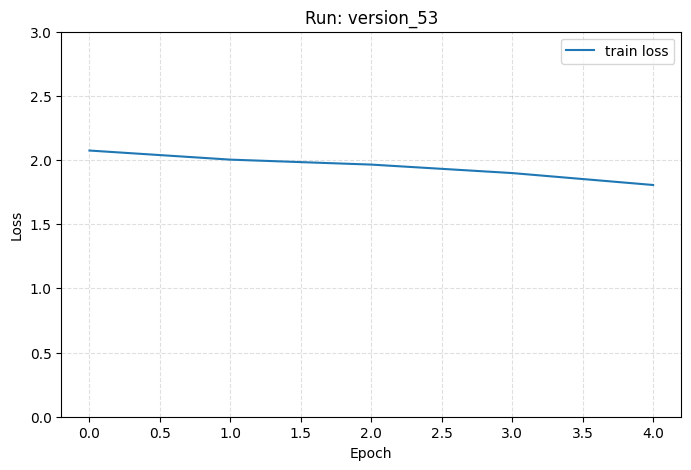

PosixPath('lightning_logs/version_53')

In [4]:
plot_latest_lightning_run()

# JetModel

In [26]:

config_path = Path("../configs/jet_model.yaml")

print(config_path.resolve())
print(config_path.exists())

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

L.seed_everything(config["training"].get("seed", 42), workers=True)

pipeline = Pipeline(config)
outputs = pipeline.run()

[rank: 0] Seed set to 42
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/scur0118/ML_project/.venv/lib64/python3.11/sit ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/gpfs/home4/scur0118/ML_project/configs/jet_model.yaml
True

classes:
0 HToBB
1 HToCC
2 HToGG
3 HToWW2Q1L
4 HToWW4Q
5 TTBar
6 TTBarLep
7 WToQQ
8 ZJetsToNuNu
9 ZToQQ


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | JetOnlyModel     | 52.1 K | train | 0    
1 | loss_fn | CrossEntropyLoss | 0      | train | 0    
-------------------------------------------------------------
52.1 K    Trainable params
0         Non-trainable params
52.1 K    Total params
0.208     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
0        


Dataset sizes:
Train: 250880
Val:   53760
Test:  53760
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), `__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.


Epoch 69: 100%|██████████| 490/490 [00:07<00:00, 62.04it/s, v_num=60, train_loss_step=1.560, train_acc_step=0.465, val_loss=2.150, val_acc=0.252, train_loss_epoch=1.620, train_acc_epoch=0.411]

`Trainer.fit` stopped: `max_epochs=70` reached.


Epoch 69: 100%|██████████| 490/490 [00:07<00:00, 61.84it/s, v_num=60, train_loss_step=1.560, train_acc_step=0.465, val_loss=2.150, val_acc=0.252, train_loss_epoch=1.620, train_acc_epoch=0.411]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 105/105 [00:00<00:00, 323.48it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.23638392984867096
        test_loss           2.1172170639038086
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


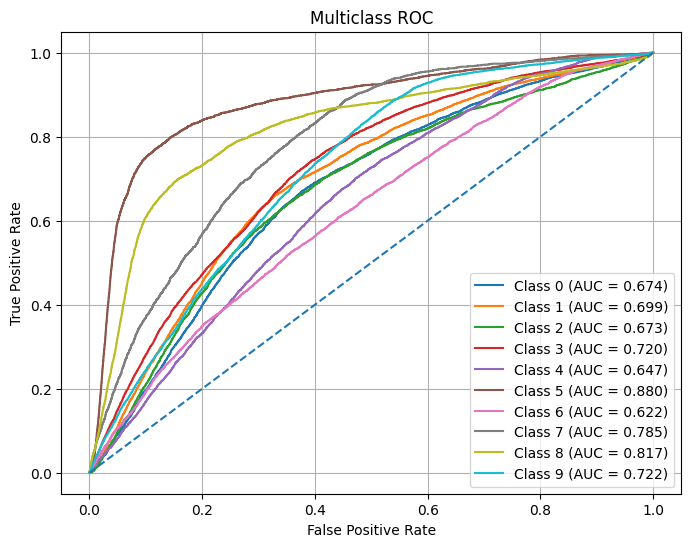

In [6]:
trainer = pipeline.lightning_model
probs = torch.cat(trainer.test_probs).numpy()
targets = torch.cat(trainer.test_targets).numpy()

plot_multiclass_roc(probs, targets)

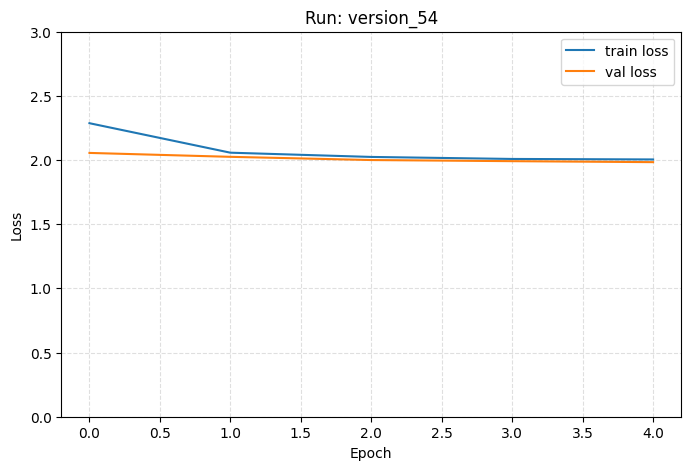

PosixPath('lightning_logs/version_54')

In [7]:
plot_latest_lightning_run()

# ParticleModel

In [8]:

config_path = Path("../configs/particle_model.yaml")

print(config_path.resolve())
print(config_path.exists())

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

L.seed_everything(config["training"].get("seed", 42), workers=True)

pipeline = Pipeline(config)
outputs = pipeline.run()

[rank: 0] Seed set to 42
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/scur0118/ML_project/.venv/lib64/python3.11/sit ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/gpfs/home4/scur0118/ML_project/configs/particle_model.yaml
True

classes:
0 HToBB
1 HToCC
2 HToGG
3 HToWW2Q1L
4 HToWW4Q
5 TTBar
6 TTBarLep
7 WToQQ
8 ZJetsToNuNu
9 ZToQQ


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name    | Type              | Params | Mode  | FLOPs
--------------------------------------------------------------
0 | model   | ParticleOnlyModel | 52.1 K | train | 0    
1 | loss_fn | CrossEntropyLoss  | 0      | train | 0    
--------------------------------------------------------------
52.1 K    Trainable params
0         Non-trainable params
52.1 K    Total params
0.208     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
0   


Dataset sizes:
Train: 250880
Val:   53760
Test:  53760
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), `__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.


Epoch 69: 100%|██████████| 490/490 [00:07<00:00, 61.54it/s, v_num=55, train_loss_step=1.060, train_acc_step=0.625, val_loss=1.190, val_acc=0.556, train_loss_epoch=1.130, train_acc_epoch=0.589]

`Trainer.fit` stopped: `max_epochs=70` reached.


Epoch 69: 100%|██████████| 490/490 [00:07<00:00, 61.30it/s, v_num=55, train_loss_step=1.060, train_acc_step=0.625, val_loss=1.190, val_acc=0.556, train_loss_epoch=1.130, train_acc_epoch=0.589]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 105/105 [00:00<00:00, 294.34it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.5797247290611267
        test_loss           1.1037391424179077
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


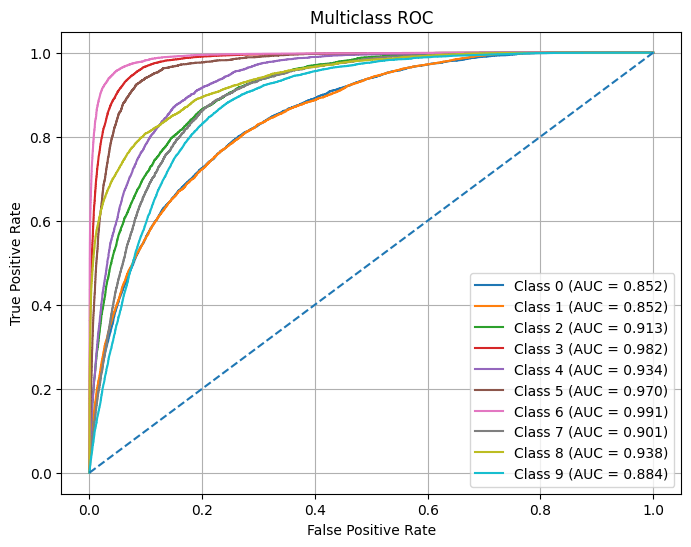

In [9]:
trainer = pipeline.lightning_model
probs = torch.cat(trainer.test_probs).numpy()
targets = torch.cat(trainer.test_targets).numpy()

plot_multiclass_roc(probs, targets)

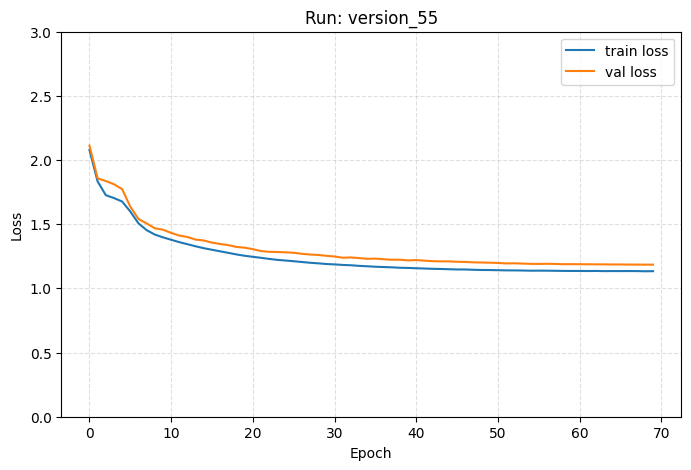

PosixPath('lightning_logs/version_55')

In [10]:
plot_latest_lightning_run()

# HybridModel

In [11]:

config_path = Path("../configs/mixed_model.yaml")

print(config_path.resolve())
print(config_path.exists())

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

L.seed_everything(config["training"].get("seed", 42), workers=True)

pipeline = Pipeline(config)
outputs = pipeline.run()

[rank: 0] Seed set to 42
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/scur0118/ML_project/.venv/lib64/python3.11/sit ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/gpfs/home4/scur0118/ML_project/configs/mixed_model.yaml
True

classes:
0 HToBB
1 HToCC
2 HToGG
3 HToWW2Q1L
4 HToWW4Q
5 TTBar
6 TTBarLep
7 WToQQ
8 ZJetsToNuNu
9 ZToQQ


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | HybridModel      | 86.3 K | train | 0    
1 | loss_fn | CrossEntropyLoss | 0      | train | 0    
-------------------------------------------------------------
86.3 K    Trainable params
0         Non-trainable params
86.3 K    Total params
0.345     Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode
0        


Dataset sizes:
Train: 250880
Val:   53760
Test:  53760
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), `__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.


Epoch 69: 100%|██████████| 490/490 [00:07<00:00, 64.15it/s, v_num=56, train_loss_step=0.990, train_acc_step=0.633, val_loss=1.540, val_acc=0.441, train_loss_epoch=1.080, train_acc_epoch=0.606]

`Trainer.fit` stopped: `max_epochs=70` reached.


Epoch 69: 100%|██████████| 490/490 [00:07<00:00, 64.07it/s, v_num=56, train_loss_step=0.990, train_acc_step=0.633, val_loss=1.540, val_acc=0.441, train_loss_epoch=1.080, train_acc_epoch=0.606]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 105/105 [00:00<00:00, 288.27it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.4634300470352173
        test_loss            1.449284315109253
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


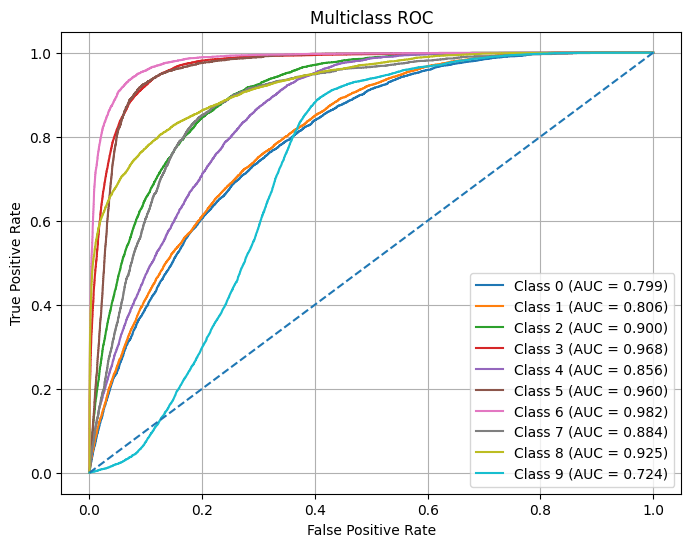

In [12]:
trainer = pipeline.lightning_model
probs = torch.cat(trainer.test_probs).numpy()
targets = torch.cat(trainer.test_targets).numpy()

plot_multiclass_roc(probs, targets)

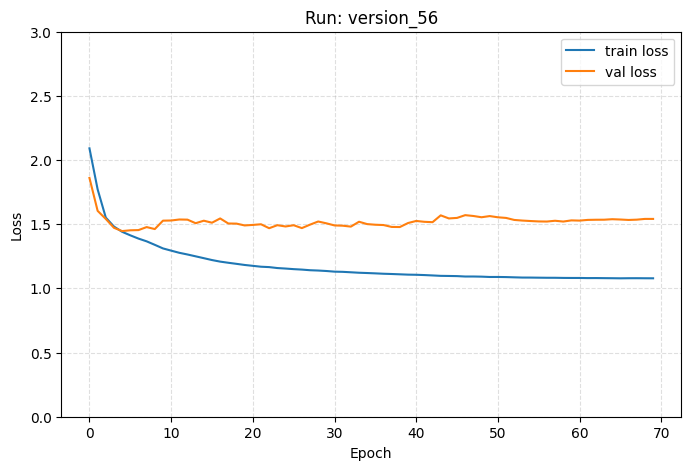

PosixPath('lightning_logs/version_56')

In [13]:
plot_latest_lightning_run()

# TransformerModel: events per file: 512

In [20]:

config_path = Path("../configs/transformer_model.yaml")

print(config_path.resolve())
print(config_path.exists())

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

L.seed_everything(config["training"].get("seed", 42), workers=True)

pipeline = Pipeline(config)
outputs = pipeline.run()

[rank: 0] Seed set to 42
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/scur0118/ML_project/.venv/lib64/python3.11/sit ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/gpfs/home4/scur0118/ML_project/configs/transformer_model.yaml
True

classes:
0 HToBB
1 HToCC
2 HToGG
3 HToWW2Q1L
4 HToWW4Q
5 TTBar
6 TTBarLep
7 WToQQ
8 ZJetsToNuNu
9 ZToQQ


/gpfs/home4/scur0118/ML_project/scs/model.py:182: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name    | Type                | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | model   | ParticleTransformer | 432 K  | train | 0    
1 | loss_fn | CrossEntropyLoss    | 0      | train | 0    
-----------------------------------------


Dataset sizes:
Train: 250880
Val:   53760
Test:  53760
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), `__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.


Epoch 69: 100%|██████████| 490/490 [00:10<00:00, 48.93it/s, v_num=58, train_loss_step=0.741, train_acc_step=0.732, val_loss=1.190, val_acc=0.578, train_loss_epoch=0.818, train_acc_epoch=0.698]

`Trainer.fit` stopped: `max_epochs=70` reached.


Epoch 69: 100%|██████████| 490/490 [00:10<00:00, 48.81it/s, v_num=58, train_loss_step=0.741, train_acc_step=0.732, val_loss=1.190, val_acc=0.578, train_loss_epoch=0.818, train_acc_epoch=0.698]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 105/105 [00:00<00:00, 222.38it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.6137834787368774
        test_loss           1.1025631427764893
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


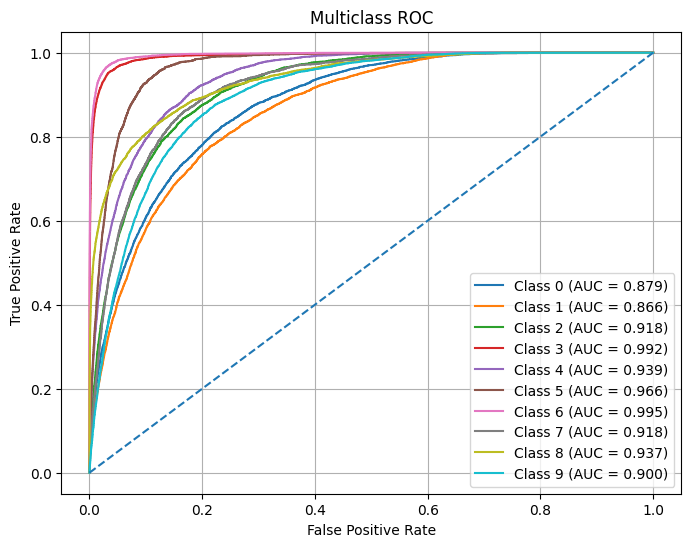

In [21]:
trainer = pipeline.lightning_model
probs = torch.cat(trainer.test_probs).numpy()
targets = torch.cat(trainer.test_targets).numpy()

plot_multiclass_roc(probs, targets)

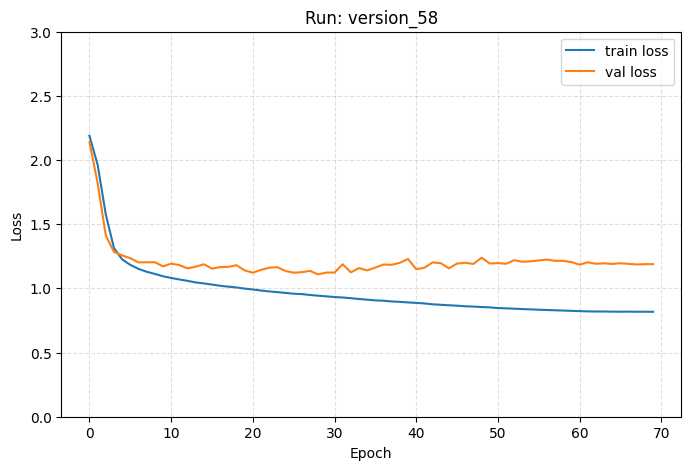

PosixPath('lightning_logs/version_58')

In [22]:
plot_latest_lightning_run()

# TransformerModel: events per file: 2028

In [14]:

config_path = Path("../configs/transformer_model.yaml")

print(config_path.resolve())
print(config_path.exists())

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

L.seed_everything(config["training"].get("seed", 42), workers=True)

pipeline = Pipeline(config)
outputs = pipeline.run()

[rank: 0] Seed set to 42
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/scur0118/ML_project/.venv/lib64/python3.11/sit ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/gpfs/home4/scur0118/ML_project/configs/transformer_model.yaml
True

classes:
0 HToBB
1 HToCC
2 HToGG
3 HToWW2Q1L
4 HToWW4Q
5 TTBar
6 TTBarLep
7 WToQQ
8 ZJetsToNuNu
9 ZToQQ


/gpfs/home4/scur0118/ML_project/scs/model.py:182: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name    | Type                | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | model   | ParticleTransformer | 432 K  | train | 0    
1 | loss_fn | CrossEntropyLoss    | 0      | train | 0    
-----------------------------------------


Dataset sizes:
Train: 993720
Val:   212940
Test:  212940
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), `__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.


Epoch 69: 100%|█████████▉| 1936/1940 [00:24<00:00, 80.56it/s, v_num=57, train_loss_step=0.532, train_acc_step=0.828, train_loss_epoch=0.866, train_acc_epoch=0.687]

`Trainer.fit` stopped: `max_epochs=70` reached.


Epoch 69: 100%|█████████▉| 1936/1940 [00:24<00:00, 80.40it/s, v_num=57, train_loss_step=0.532, train_acc_step=0.828, train_loss_epoch=0.866, train_acc_epoch=0.687]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 416/416 [00:02<00:00, 160.07it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc             0.619291365146637
        test_loss           1.0637438297271729
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


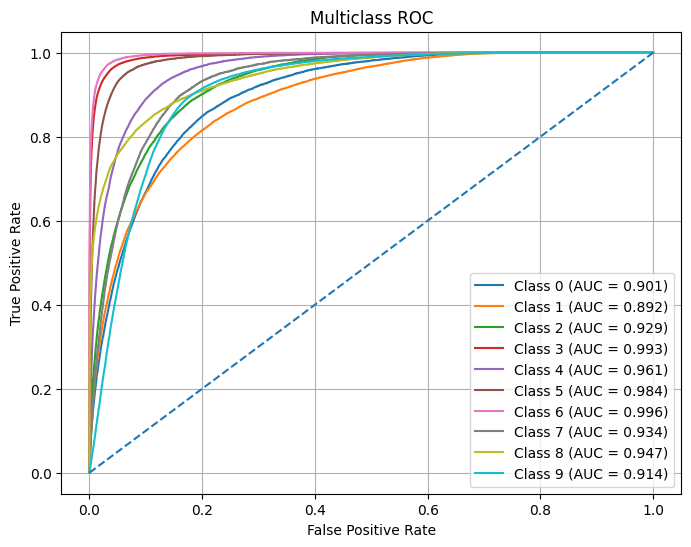

In [15]:
trainer = pipeline.lightning_model
probs = torch.cat(trainer.test_probs).numpy()
targets = torch.cat(trainer.test_targets).numpy()

plot_multiclass_roc(probs, targets)

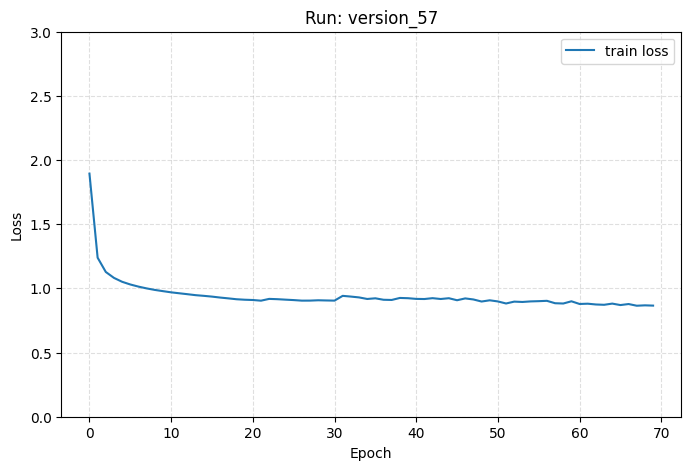

PosixPath('lightning_logs/version_57')

In [16]:
plot_latest_lightning_run()

# TransformerModel: events per file: 512 --  max

In [23]:

config_path = Path("../configs/transformer_model.yaml")

print(config_path.resolve())
print(config_path.exists())

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

L.seed_everything(config["training"].get("seed", 42), workers=True)

pipeline = Pipeline(config)
outputs = pipeline.run()

[rank: 0] Seed set to 42
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/scur0118/ML_project/.venv/lib64/python3.11/sit ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/gpfs/home4/scur0118/ML_project/configs/transformer_model.yaml
True

classes:
0 HToBB
1 HToCC
2 HToGG
3 HToWW2Q1L
4 HToWW4Q
5 TTBar
6 TTBarLep
7 WToQQ
8 ZJetsToNuNu
9 ZToQQ


/gpfs/home4/scur0118/ML_project/scs/model.py:182: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name    | Type                | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | model   | ParticleTransformer | 432 K  | train | 0    
1 | loss_fn | CrossEntropyLoss    | 0      | train | 0    
-----------------------------------------


Dataset sizes:
Train: 250880
Val:   53760
Test:  53760
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), `__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.


Epoch 69: 100%|██████████| 490/490 [00:09<00:00, 49.72it/s, v_num=59, train_loss_step=0.772, train_acc_step=0.730, val_loss=3.540, val_acc=0.262, train_loss_epoch=0.853, train_acc_epoch=0.688]

`Trainer.fit` stopped: `max_epochs=70` reached.


Epoch 69: 100%|██████████| 490/490 [00:09<00:00, 49.60it/s, v_num=59, train_loss_step=0.772, train_acc_step=0.730, val_loss=3.540, val_acc=0.262, train_loss_epoch=0.853, train_acc_epoch=0.688]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 105/105 [00:00<00:00, 222.66it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.3064732253551483
        test_loss            3.325864315032959
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


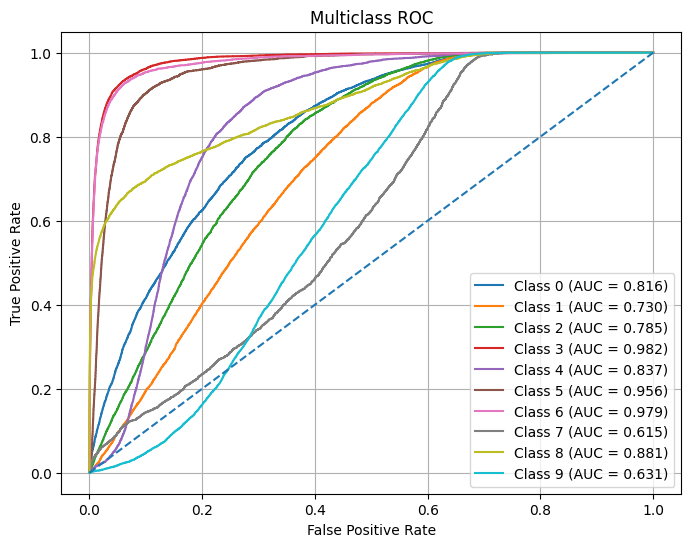

In [24]:
trainer = pipeline.lightning_model
probs = torch.cat(trainer.test_probs).numpy()
targets = torch.cat(trainer.test_targets).numpy()

plot_multiclass_roc(probs, targets)

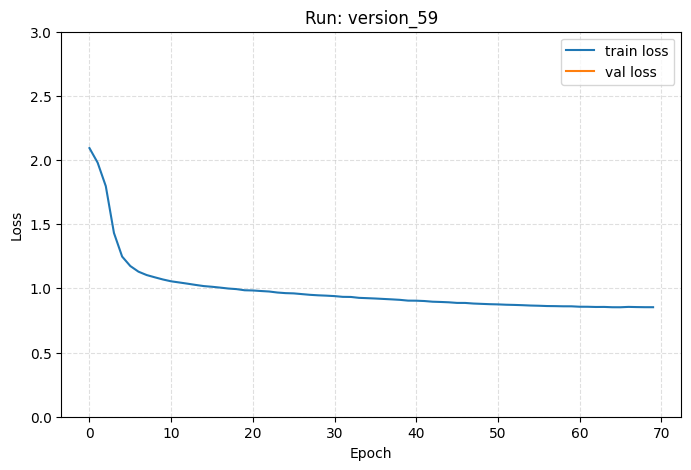

PosixPath('lightning_logs/version_59')

In [25]:
plot_latest_lightning_run()